# 🎯 Affine Transformations in OpenCV - Complete Guide

## 📚 What You'll Learn

In this notebook, you will master:
- ✅ What affine transformations are
- ✅ How to rotate, scale, translate, and shear images
- ✅ Difference between affine and perspective transforms
- ✅ Real-world applications (image alignment, data augmentation)
- ✅ Hands-on examples with detailed explanations

---

## 🧠 Theory: What is Affine Transformation?

An **affine transformation** is a geometric operation that:

### Preserves:
- **Straight lines** (lines remain lines, not curves)
- **Parallelism** (parallel lines stay parallel)
- **Ratios of distances** along lines

### Allows:
- **Rotation** - Turn the image
- **Scaling** - Make it bigger/smaller
- **Translation** - Move it around
- **Shearing** - Skew/slant the image

### Key Formula:
Where:
- `(x, y)` = original point
- `(x', y')` = transformed point
- `a, b, c, d` = transformation parameters
- `tx, ty` = translation (shift)

---

## 🔑 Key Difference

| Transform Type | Points Needed | Preserves | Use Case |
|---------------|---------------|-----------|----------|
| **Affine** | 3 points | Parallel lines | Rotation, scaling, shear |
| **Perspective** | 4 points | Vanishing points | Document scanning, 3D effects |

---

## 📦 Let's Start!

In [1]:
# ============================================
# IMPORT LIBRARIES
# ============================================

import cv2                    # OpenCV for image processing
import numpy as np            # NumPy for numerical operations
import matplotlib.pyplot as plt  # Matplotlib for displaying images

# Configure matplotlib to display images inline in notebook
%matplotlib inline

# Set default figure size for better visibility
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ All libraries imported successfully!")
print(f"OpenCV version: {cv2.__version__}")
print(f"NumPy version: {np.__version__}")

✅ All libraries imported successfully!
OpenCV version: 5.0.0
NumPy version: 2.5.1


In [2]:
# ============================================
# HELPER FUNCTION: Display Multiple Images
# ============================================

def show_images(images, titles, figsize=(15, 5), cmap=None):
    """
    Display multiple images side by side in a single row.
    
    Parameters:
    -----------
    images : list
        List of images to display (numpy arrays)
    titles : list
        List of titles for each image
    figsize : tuple, optional
        Figure size as (width, height). Default is (15, 5)
    cmap : str, optional
        Colormap for grayscale images. Use 'gray' for grayscale
    
    Example:
    --------
    show_images([img1, img2], ['Original', 'Transformed'])
    """
    n = len(images)
    plt.figure(figsize=figsize)
    
    for i in range(n):
        plt.subplot(1, n, i + 1)
        
        # Check if image is color (3 channels) or grayscale
        if len(images[i].shape) == 3:
            # Convert BGR to RGB for proper color display
            plt.imshow(cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB))
        else:
            # Display grayscale image
            plt.imshow(images[i], cmap='gray')
        
        plt.title(titles[i], fontsize=12, fontweight='bold')
        plt.axis('off')  # Hide axes
    
    plt.tight_layout()
    plt.show()

print("✅ Helper function created!")

✅ Helper function created!


---

## 🖼️ Step 1: Create a Sample Image

We'll create a simple image with geometric shapes to clearly see the transformations.

### Alternative:
If you have your own image, replace the code below with:
```python
img = cv2.imread('path/to/your/image.jpg')

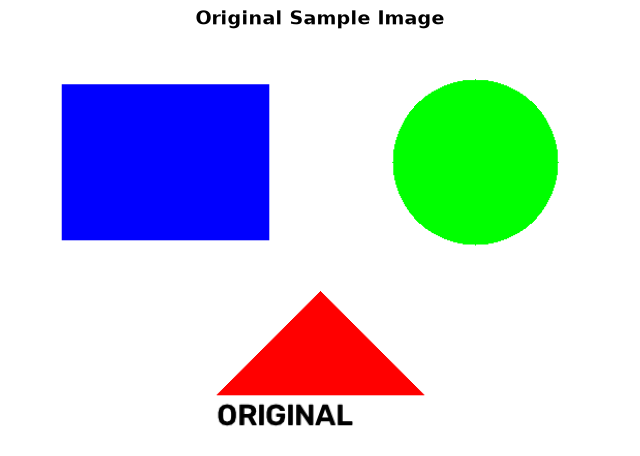

📐 Image dimensions: 600 x 400 pixels (width x height)


In [3]:
# ============================================
# CREATE A SAMPLE IMAGE WITH SHAPES
# ============================================

# Create a blank white canvas (400 height x 600 width x 3 color channels)
img = np.ones((400, 600, 3), dtype=np.uint8) * 255

# Draw a blue rectangle
# Syntax: cv2.rectangle(image, top_left, bottom_right, color_BGR, thickness)
cv2.rectangle(img, (50, 50), (250, 200), (255, 0, 0), -1)  # -1 = filled

# Draw a green circle
# Syntax: cv2.circle(image, center, radius, color_BGR, thickness)
cv2.circle(img, (450, 125), 80, (0, 255, 0), -1)

# Draw a red triangle
triangle_points = np.array([[300, 250], [400, 350], [200, 350]], np.int32)
cv2.fillPoly(img, [triangle_points], (0, 0, 255))

# Add text label
cv2.putText(img, 'ORIGINAL', (200, 380), 
            cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 0), 2)

# Display the image
plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Original Sample Image', fontsize=14, fontweight='bold')
plt.axis('off')
plt.show()

# Store image dimensions for later use
rows, cols = img.shape[:2]  # height, width
print(f"📐 Image dimensions: {cols} x {rows} pixels (width x height)")

## 🔄 Example 1: Basic Affine Transform

### 🎯 Concept:
To perform an affine transformation, you need:
1. **3 source points** - Where points are NOW in the original image
2. **3 destination points** - Where you WANT them to be
3. OpenCV calculates the transformation matrix automatically
4. Apply the matrix to warp the entire image

### 🔧 Key Functions:
```python
# Step 1: Get transformation matrix
M = cv2.getAffineTransform(src_points, dst_points)

# Step 2: Apply transformation
result = cv2.warpAffine(img, M, (width, height))

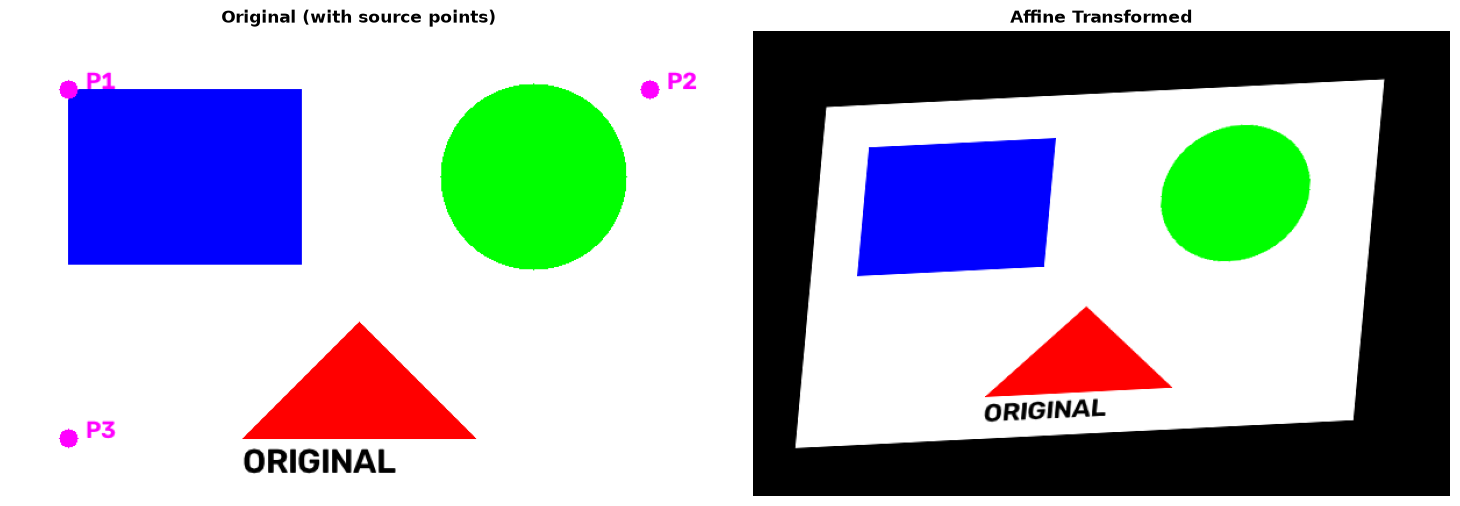

🔢 Transformation Matrix (2x3):
[[ 8.00000000e-01 -6.66666667e-02  6.33333333e+01]
 [-4.00000000e-02  7.33333333e-01  6.53333333e+01]]

This matrix transforms any point (x,y) to its new position (x',y')


In [4]:
# ============================================
# BASIC AFFINE TRANSFORMATION
# ============================================

# Define 3 source points (forming a triangle in the original image)
# These are the corners we're tracking
src_points = np.float32([
    [50, 50],      # Point 1: Top-left area
    [550, 50],     # Point 2: Top-right area
    [50, 350]      # Point 3: Bottom-left area
])

# Define 3 destination points (where we want those points to move)
dst_points = np.float32([
    [100, 100],    # Point 1 moves here (shifted right and down)
    [500, 80],     # Point 2 moves here (shifted left and down)
    [80, 320]      # Point 3 moves here (shifted right and up)
])

# Calculate the affine transformation matrix
# This matrix describes how to transform ANY point in the image
M = cv2.getAffineTransform(src_points, dst_points)

# Apply the transformation to the entire image
transformed = cv2.warpAffine(img, M, (cols, rows))

# Visualize the source points on the original image
img_with_points = img.copy()
for i, point in enumerate(src_points):
    # Draw circles at each source point
    cv2.circle(img_with_points, tuple(point.astype(int)), 8, (255, 0, 255), -1)
    # Label each point
    cv2.putText(img_with_points, f'P{i+1}', 
                (int(point[0])+15, int(point[1])), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 255), 2)

# Display results
show_images([img_with_points, transformed], 
            ['Original (with source points)', 'Affine Transformed'])

print("🔢 Transformation Matrix (2x3):")
print(M)
print("\nThis matrix transforms any point (x,y) to its new position (x',y')")

---

## 🔄 Example 2: Image Rotation (Simple)

### 🎯 Concept:
Rotation is a **special case** of affine transformation!

### 🔧 Function:
```python
cv2.getRotationMatrix2D(center, angle, scale)

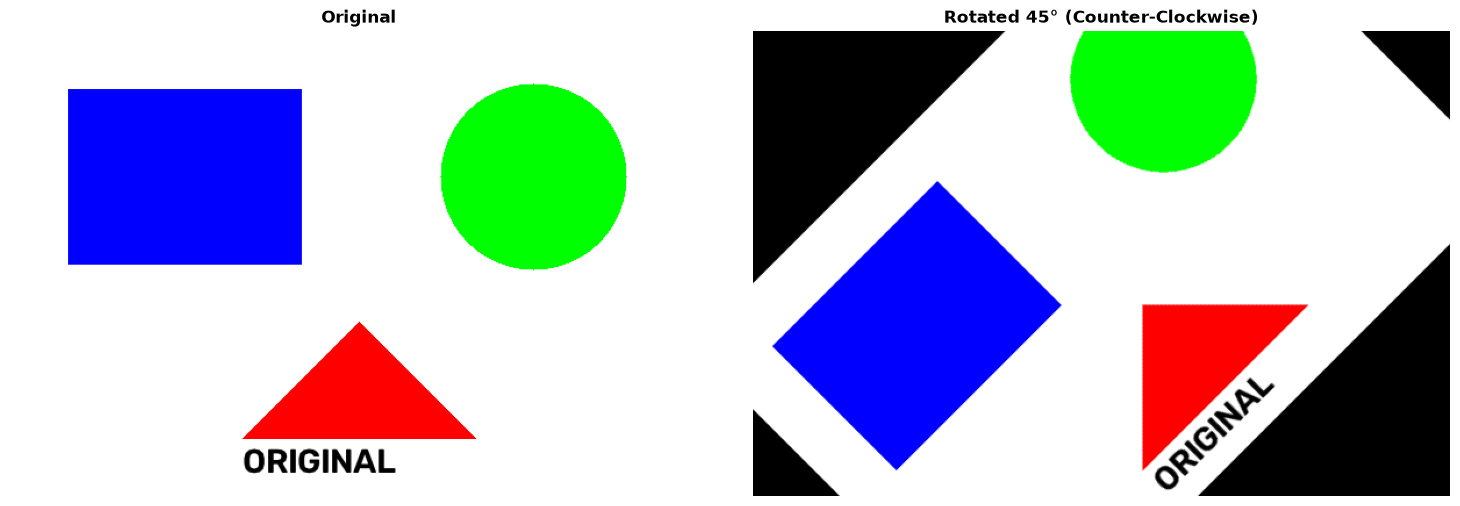

🔄 Rotated 45° around center point (300, 200)
⚠️  Notice: Corners are cropped!

🔢 Rotation Matrix:
[[  0.70710678   0.70710678 -53.55339059]
 [ -0.70710678   0.70710678 270.71067812]]


In [5]:
# ============================================
# SIMPLE ROTATION
# ============================================

# Define rotation parameters
center = (cols // 2, rows // 2)  # Center point of the image
angle = 45                        # Rotate 45 degrees counter-clockwise
scale = 1.0                       # Keep original size (no scaling)

# Get the rotation matrix
# This is a 2x3 affine transformation matrix
M_rotate = cv2.getRotationMatrix2D(center, angle, scale)

# Apply the rotation
rotated = cv2.warpAffine(img, M_rotate, (cols, rows))

# Display results
show_images([img, rotated], 
            ['Original', f'Rotated {angle}° (Counter-Clockwise)'])

print(f"🔄 Rotated {angle}° around center point {center}")
print(f"⚠️  Notice: Corners are cropped!")
print("\n🔢 Rotation Matrix:")
print(M_rotate)


## 🔄 Example 3: Rotation WITHOUT Cropping

### ❌ Problem:
The previous rotation **cut off the corners**!

### ✅ Solution:
1. Calculate how much bigger the canvas needs to be
2. Adjust the transformation matrix to center the rotated image
3. Apply transformation with the new, larger dimensions

### 🧮 Math Behind It:
new_width = (height × |sin(θ)|) + (width × |cos(θ)|)

new_height = (height × |cos(θ)|) + (width × |sin(θ)|)

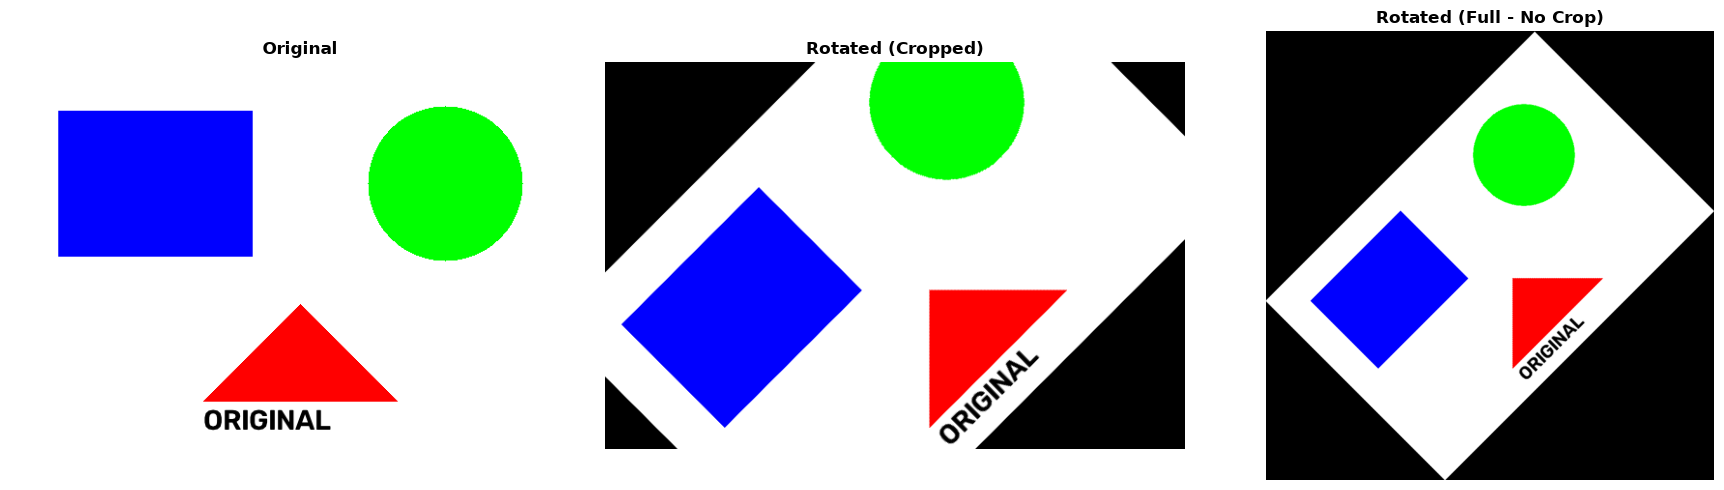

📐 Original size: 600 x 400 pixels
📐 New size: 707 x 707 pixels
✅ No corners cropped!


In [6]:
# ============================================
# ROTATION WITHOUT CROPPING
# ============================================

# Rotation parameters
center = (cols // 2, rows // 2)
angle = 45
scale = 1.0

# Get the rotation matrix
M = cv2.getRotationMatrix2D(center, angle, scale)

# Calculate the sine and cosine (rotation components)
cos = np.abs(M[0, 0])
sin = np.abs(M[0, 1])

# Calculate new bounding dimensions
# This ensures the entire rotated image fits
new_width = int((rows * sin) + (cols * cos))
new_height = int((rows * cos) + (cols * sin))

# Adjust the transformation matrix for the new center
# We need to shift the image to center it in the new canvas
M[0, 2] += (new_width / 2) - center[0]   # Adjust x translation
M[1, 2] += (new_height / 2) - center[1]  # Adjust y translation

# Apply rotation with the new dimensions
rotated_full = cv2.warpAffine(img, M, (new_width, new_height))

# Compare: cropped vs full rotation
show_images([img, rotated, rotated_full], 
            ['Original', 'Rotated (Cropped)', 'Rotated (Full - No Crop)'],
            figsize=(18, 5))

print(f"📐 Original size: {cols} x {rows} pixels")
print(f"📐 New size: {new_width} x {new_height} pixels")
print(f"✅ No corners cropped!")

---

## 📐 Example 4: Shearing (Skew Effect)

### 🎯 Concept:
**Shearing** makes the image look "slanted" - like pushing the top of a rectangle sideways while keeping the bottom fixed.

### 📊 Types:

#### 1. **Horizontal Shear**
- Top or bottom edge shifts left/right
- Creates a "leaning" effect
- Like italic text

#### 2. **Vertical Shear**
- Left or right edge shifts up/down
- Creates a "tilted" effect

### 🔧 How It Works:
We define 3 points where:
- 2 points stay in place
- 1 point shifts (creating the shear)

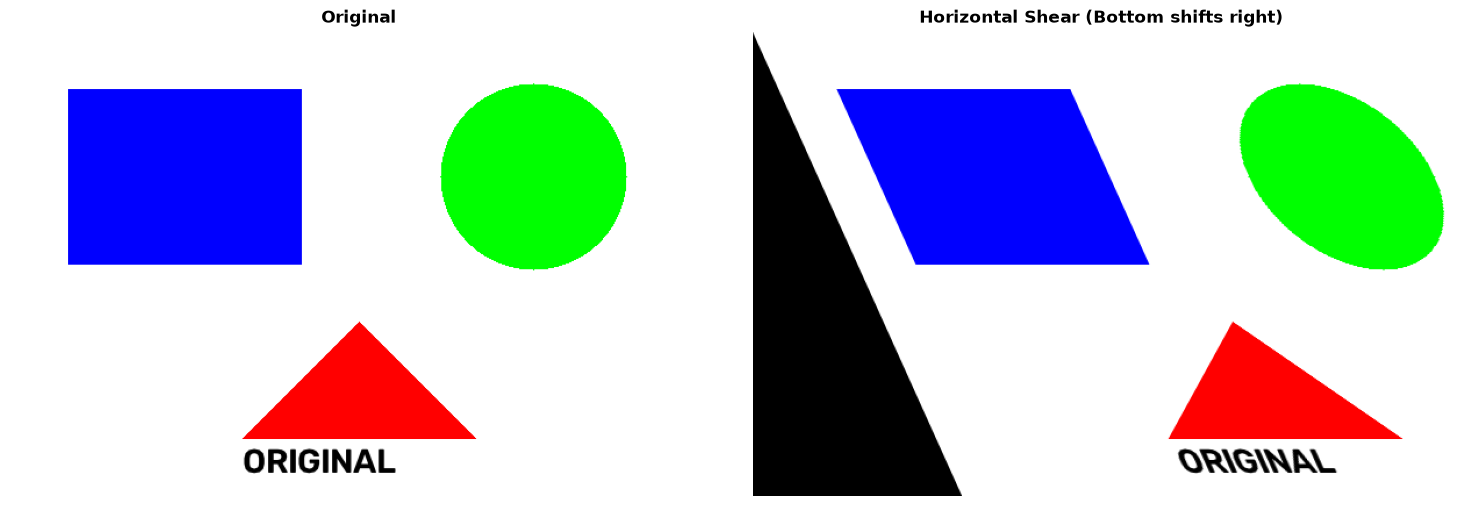

📐 Horizontal Shear Applied
Bottom-left corner shifted right by 30% of image width


In [7]:
# ============================================
# HORIZONTAL SHEAR
# ============================================

# Define source points (corners of the original image)
src_points = np.float32([
    [0, 0],           # Top-left corner
    [cols-1, 0],      # Top-right corner
    [0, rows-1]       # Bottom-left corner
])

# Define destination points
# Top stays fixed, bottom-left shifts right → horizontal shear
dst_points = np.float32([
    [0, 0],              # Top-left stays in place
    [cols-1, 0],         # Top-right stays in place
    [cols*0.3, rows-1]   # Bottom-left shifts RIGHT (30% of width)
])

# Get transformation matrix
M_shear_h = cv2.getAffineTransform(src_points, dst_points)

# Apply horizontal shearing
sheared_h = cv2.warpAffine(img, M_shear_h, (cols, rows))

# Display
show_images([img, sheared_h], 
            ['Original', 'Horizontal Shear (Bottom shifts right)'])

print("📐 Horizontal Shear Applied")
print("Bottom-left corner shifted right by 30% of image width")

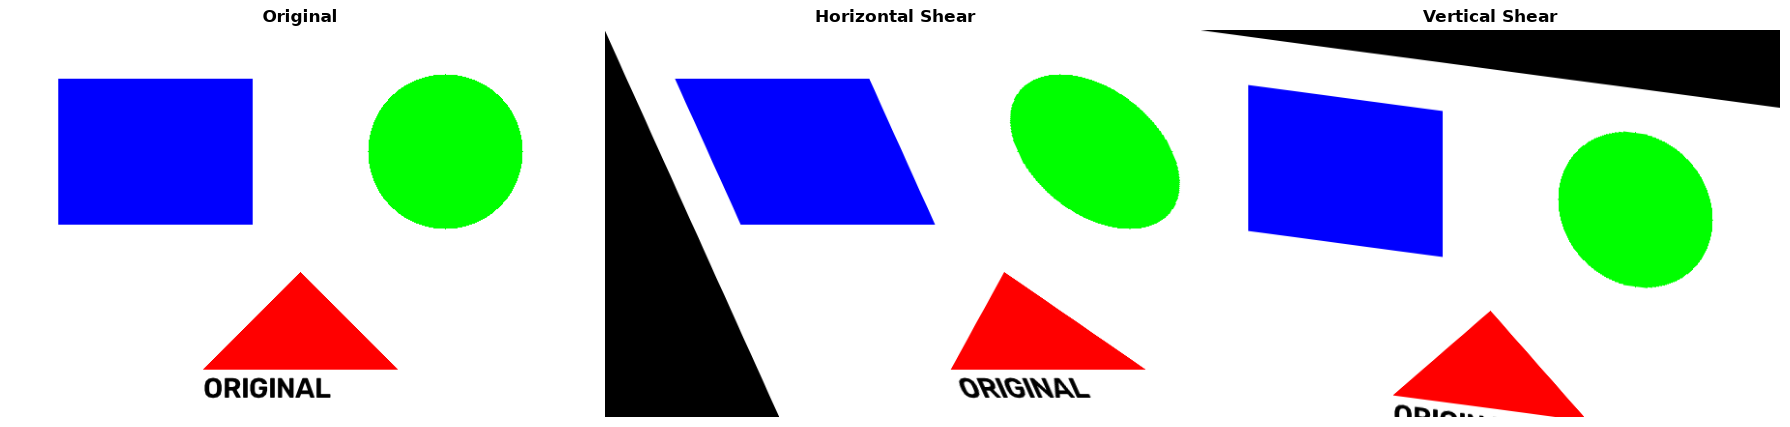

📐 Vertical Shear Applied
Top-right corner shifted down by 20% of image height


In [8]:
# ============================================
# VERTICAL SHEAR
# ============================================

# Source points
src_points = np.float32([
    [0, 0],
    [cols-1, 0],
    [0, rows-1]
])

# Destination points
# Left side stays fixed, top-right shifts down → vertical shear
dst_points = np.float32([
    [0, 0],                # Top-left stays in place
    [cols-1, rows*0.2],    # Top-right shifts DOWN (20% of height)
    [0, rows-1]            # Bottom-left stays in place
])

# Get transformation matrix
M_shear_v = cv2.getAffineTransform(src_points, dst_points)

# Apply vertical shearing
sheared_v = cv2.warpAffine(img, M_shear_v, (cols, rows))

# Display both types of shear
show_images([img, sheared_h, sheared_v], 
            ['Original', 'Horizontal Shear', 'Vertical Shear'],
            figsize=(18, 5))

print("📐 Vertical Shear Applied")
print("Top-right corner shifted down by 20% of image height")

---

## 🔍 Example 5: Scaling with Affine Transform

### 🎯 Concept:
You can use affine transformation for scaling (resizing)!

### 🆚 Comparison:

| Method | Pros | Cons |
|--------|------|------|
| `cv2.resize()` | Simple, fast, dedicated function | Only scales |
| Affine Transform | Can combine with rotation/translation | Slightly more complex |

### 💡 When to use Affine for scaling:
- When you need to scale AND rotate/translate in one step
- When you want precise control over transformation
- For learning purposes (understanding the math)

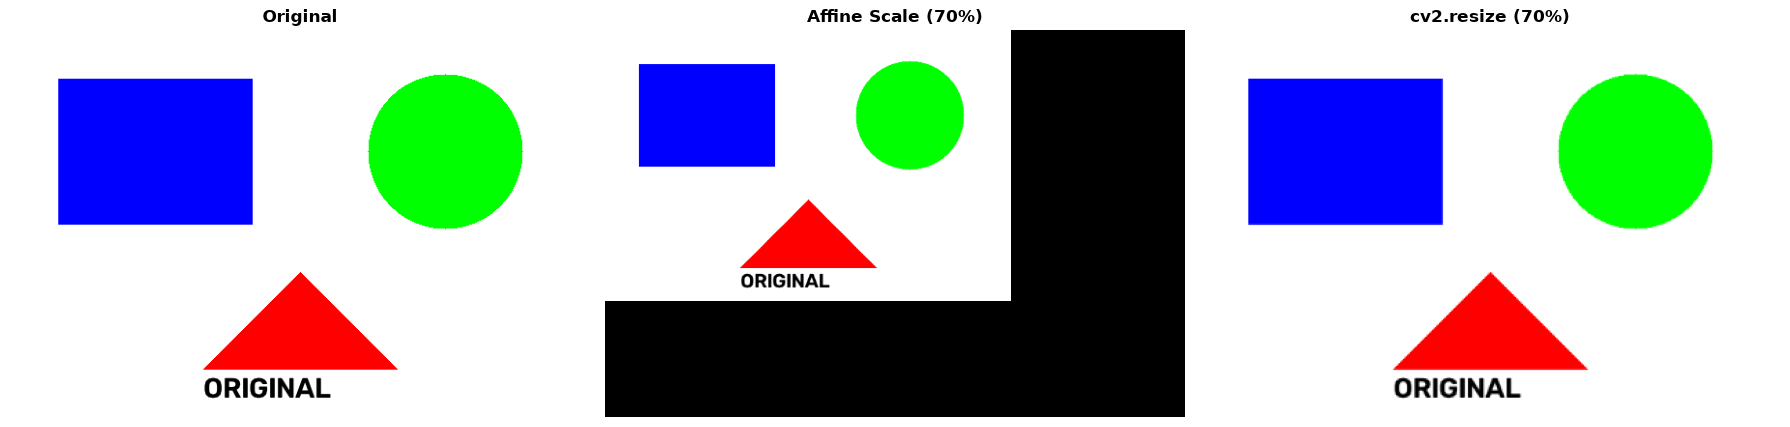

🔍 Scaled to 70% of original size
Original: 600x400 → Scaled: 420x280


In [9]:
# ============================================
# SCALING USING AFFINE TRANSFORM
# ============================================

# Scale factor (0.7 = 70% of original size)
scale_factor = 0.7

# Define source points (original corners)
src_points = np.float32([
    [0, 0],
    [cols-1, 0],
    [0, rows-1]
])

# Define destination points (scaled positions)
dst_points = np.float32([
    [0, 0],
    [(cols-1) * scale_factor, 0],           # Scale width
    [0, (rows-1) * scale_factor]            # Scale height
])

# Get transformation matrix
M_scale = cv2.getAffineTransform(src_points, dst_points)

# Apply scaling
scaled = cv2.warpAffine(img, M_scale, (cols, rows))

# Compare with cv2.resize()
scaled_resize = cv2.resize(img, None, fx=scale_factor, fy=scale_factor)

# Display
show_images([img, scaled, scaled_resize], 
            ['Original', f'Affine Scale ({int(scale_factor*100)}%)', 
             f'cv2.resize ({int(scale_factor*100)}%)'],
            figsize=(18, 5))

print(f"🔍 Scaled to {int(scale_factor*100)}% of original size")
print(f"Original: {cols}x{rows} → Scaled: {int(cols*scale_factor)}x{int(rows*scale_factor)}")

---

## 🎯 Example 6: Combined Transformation

### 🎯 Concept:
The **real power** of affine transforms: combine multiple operations in ONE step!

### 🔗 What we'll combine:
1. **Rotation** - Turn the image
2. **Scaling** - Make it smaller
3. **Translation** - Shift it

### ⚡ Advantage:
- Single transformation = faster
- No quality loss from multiple operations
- More efficient than doing them separately

### 🧮 How:
The `getRotationMatrix2D` function already combines rotation + scaling!
We just add translation by modifying the matrix.

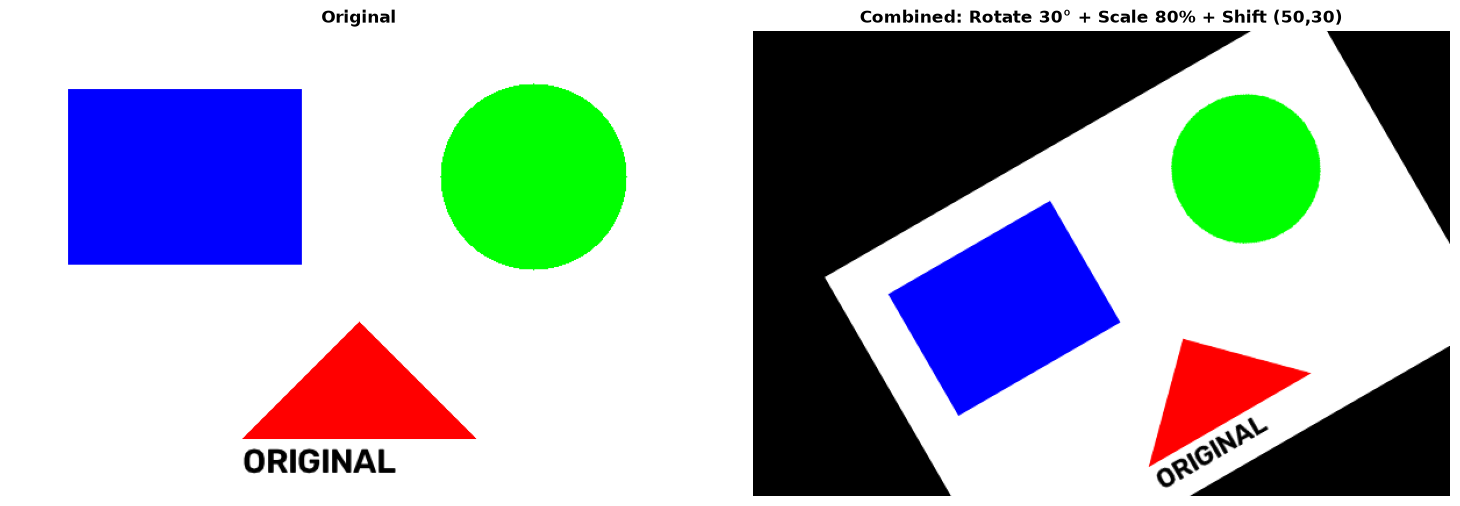

🎯 Combined Transformation Applied!
   ↻ Rotation: 30°
   🔍 Scale: 80%
   ➡️  Translation: (50, 30) pixels

🔢 Combined Transformation Matrix:
[[  0.69282032   0.4         62.15390309]
 [ -0.4          0.69282032 211.43593539]]


In [10]:
# ============================================
# COMBINED TRANSFORMATION
# (Rotation + Scaling + Translation)
# ============================================

# Define transformation parameters
center = (cols // 2, rows // 2)
rotation_angle = 30      # Rotate 30 degrees
scale_factor = 0.8       # Scale to 80%
shift_x = 50             # Shift right by 50 pixels
shift_y = 30             # Shift down by 30 pixels

# Get rotation + scaling matrix
M_combined = cv2.getRotationMatrix2D(center, rotation_angle, scale_factor)

# Add translation (shift)
M_combined[0, 2] += shift_x  # Modify x translation
M_combined[1, 2] += shift_y  # Modify y translation

# Apply combined transformation
combined = cv2.warpAffine(img, M_combined, (cols, rows))

# Display
show_images([img, combined], 
            ['Original', 
             f'Combined: Rotate {rotation_angle}° + Scale {int(scale_factor*100)}% + Shift ({shift_x},{shift_y})'])

print("🎯 Combined Transformation Applied!")
print(f"   ↻ Rotation: {rotation_angle}°")
print(f"   🔍 Scale: {int(scale_factor*100)}%")
print(f"   ➡️  Translation: ({shift_x}, {shift_y}) pixels")
print("\n🔢 Combined Transformation Matrix:")
print(M_combined)


---

## 📄 Example 7: Perspective Transform (BONUS!)

### ⚠️ Important:
This is **NOT** an affine transform, but it's super useful to know!

### 🆚 Key Difference:

| Feature | Affine | Perspective |
|---------|--------|-------------|
| Points needed | **3** | **4** |
| Preserves | Parallel lines | Vanishing points |
| Function | `getAffineTransform()` | `getPerspectiveTransform()` |
| Apply with | `warpAffine()` | `warpPerspective()` |

### 🎯 Use Cases:
- 📄 Document scanning (correct skewed photos)
- 🚗 Bird's eye view (dashcam footage)
- 🏢 Architectural correction
- 🎮 3D-like effects

### 🔧 Functions:
```python
M = cv2.getPerspectiveTransform(src_points, dst_points)  # 4 points!
result = cv2.warpPerspective(img, M, (width, height))

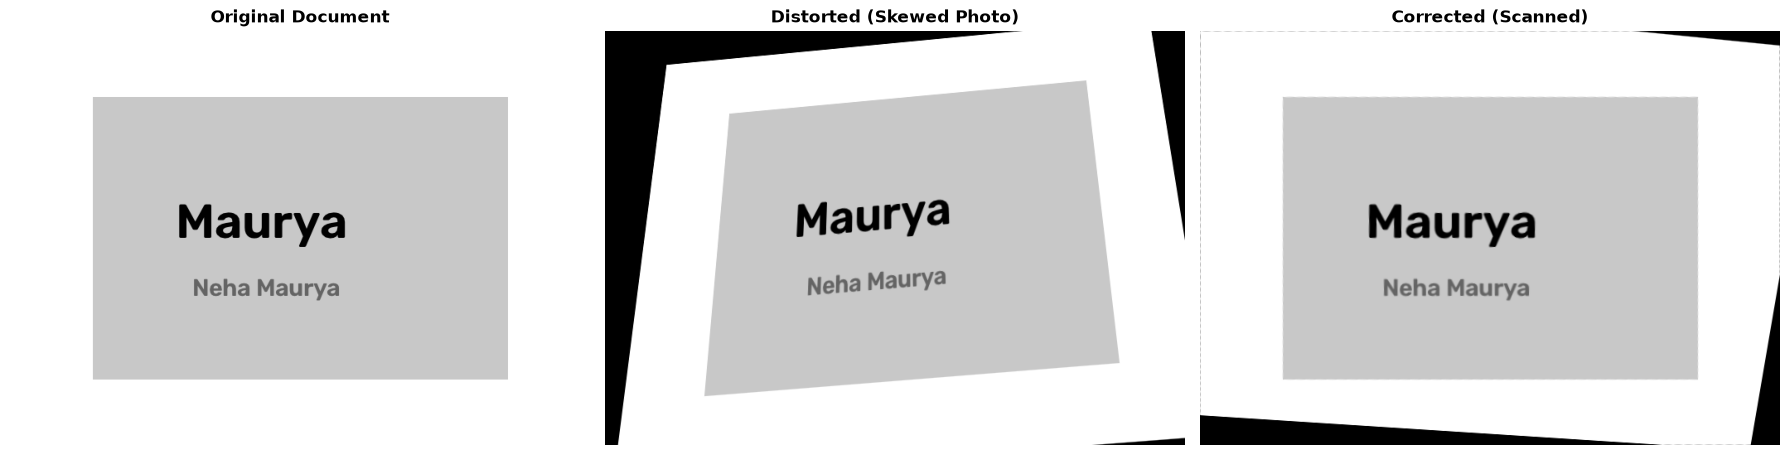

📄 Perspective Transform Demonstration
✅ This is how document scanning apps work!
   1. Take a photo of a document (even at an angle)
   2. Detect 4 corners
   3. Apply perspective transform to make it rectangular


In [12]:
# ============================================
# PERSPECTIVE TRANSFORM
# ============================================

# Create a "document" image
doc_img = np.ones((500, 700, 3), dtype=np.uint8) * 255

# Draw a document with text
cv2.rectangle(doc_img, (100, 80), (600, 420), (200, 200, 200), -1)
cv2.putText(doc_img, 'Maurya', (200, 250), 
            cv2.FONT_HERSHEY_SIMPLEX, 2, (0, 0, 0), 3)
cv2.putText(doc_img, 'Neha Maurya', (220, 320), 
            cv2.FONT_HERSHEY_SIMPLEX, 1, (100, 100, 100), 2)

# Define 4 corners of the document (rectangle)
src_pts = np.float32([
    [100, 80],    # Top-left
    [600, 80],    # Top-right
    [100, 420],   # Bottom-left
    [600, 420]    # Bottom-right
])

# Define distorted positions (simulate a photo taken at an angle)
dst_pts = np.float32([
    [150, 100],   # Top-left shifted
    [580, 60],    # Top-right shifted
    [120, 440],   # Bottom-left shifted
    [620, 400]    # Bottom-right shifted
])

# Create distorted version (simulate skewed photo)
M_distort = cv2.getPerspectiveTransform(src_pts, dst_pts)
distorted = cv2.warpPerspective(doc_img, M_distort, (700, 500))

# Now correct it back to rectangle!
M_correct = cv2.getPerspectiveTransform(dst_pts, src_pts)
corrected = cv2.warpPerspective(distorted, M_correct, (700, 500))

# Display the transformation pipeline
show_images([doc_img, distorted, corrected], 
            ['Original Document', 'Distorted (Skewed Photo)', 'Corrected (Scanned)'],
            figsize=(18, 5))

print("📄 Perspective Transform Demonstration")
print("✅ This is how document scanning apps work!")
print("   1. Take a photo of a document (even at an angle)")
print("   2. Detect 4 corners")
print("   3. Apply perspective transform to make it rectangular")

## 🎨 Example 8: Image Alignment

### 🎯 Real-World Application:
Align two images that show the same scene but from different angles or positions.

### 📋 Use Cases:
- 🏥 **Medical imaging** - Align MRI/CT scans
- 🗺️ **Panorama stitching** - Combine multiple photos
- 👤 **Face alignment** - Normalize face positions for recognition
- 🛰️ **Satellite imagery** - Register images from different times

### 🔧 Process:
1. Identify corresponding points in both images
2. Calculate transformation matrix
3. Warp one image to align with the other

### 💡 Note:
In real applications, you'd use feature detection (SIFT, ORB) to find corresponding points automatically!

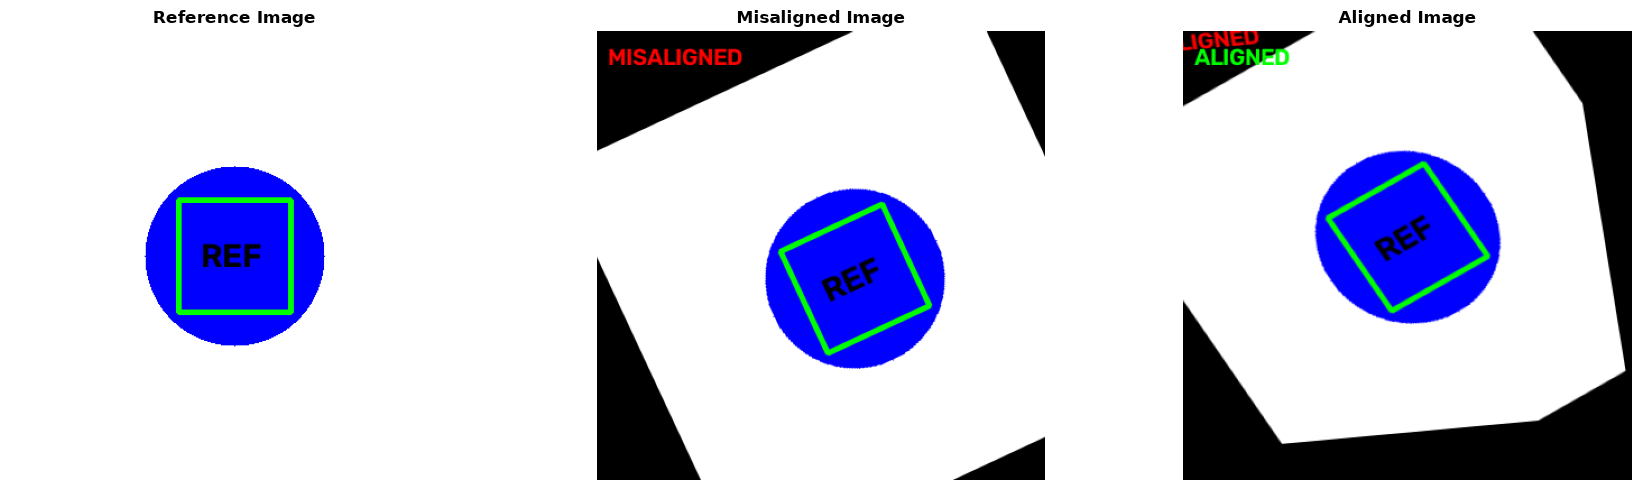

🎯 Image Alignment Complete!
✅ Image 2 has been aligned to match Image 1
   Used 3 corresponding points


In [13]:
# ============================================
# IMAGE ALIGNMENT
# ============================================

# Create reference image (Image 1)
img1 = np.ones((400, 400, 3), dtype=np.uint8) * 255
cv2.circle(img1, (200, 200), 80, (255, 0, 0), -1)
cv2.rectangle(img1, (150, 150), (250, 250), (0, 255, 0), 3)
cv2.putText(img1, 'REF', (170, 210), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 0), 2)

# Create a rotated and shifted version (Image 2 - misaligned)
center = (200, 200)
M_temp = cv2.getRotationMatrix2D(center, 25, 1.0)  # Rotate 25°
M_temp[0, 2] += 30  # Shift right
M_temp[1, 2] += 20  # Shift down
img2 = cv2.warpAffine(img1, M_temp, (400, 400))

# Add label to misaligned image
cv2.putText(img2, 'MISALIGNED', (10, 30), 
            cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)

# Define corresponding points
# In real scenarios, you'd detect these automatically using feature matching
pts_img1 = np.float32([
    [200, 120],  # Top of circle in reference image
    [280, 200],  # Right of circle
    [200, 280]   # Bottom of circle
])

# These are where those same points appear in the misaligned image
pts_img2 = np.float32([
    [240, 155],  # Top of circle in misaligned image
    [305, 245],  # Right of circle
    [215, 320]   # Bottom of circle
])

# Calculate alignment transformation
M_align = cv2.getAffineTransform(pts_img2, pts_img1)

# Align img2 to match img1
img2_aligned = cv2.warpAffine(img2, M_align, (400, 400))

# Add label to aligned image
cv2.putText(img2_aligned, 'ALIGNED', (10, 30), 
            cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

# Display the alignment process
show_images([img1, img2, img2_aligned], 
            ['Reference Image', 'Misaligned Image', 'Aligned Image'],
            figsize=(18, 5))

print("🎯 Image Alignment Complete!")
print("✅ Image 2 has been aligned to match Image 1")
print(f"   Used {len(pts_img1)} corresponding points")

## 🎲 Example 9: Data Augmentation for Machine Learning

### 🎯 Purpose:
In machine learning, we create **variations** of training images to:
- ✅ Increase dataset size
- ✅ Improve model robustness
- ✅ Prevent overfitting
- ✅ Simulate real-world variations

### 🔄 Common Augmentations:
- **Random rotation** (-15° to +15°)
- **Random scaling** (90% to 110%)
- **Random translation** (shift in any direction)
- **Random shearing** (slight skew)

### 💡 Why Affine Transform?
- Fast and efficient
- Maintains image quality
- Easy to control randomness
- Industry standard for augmentation

### 🎯 Use in:
- Image classification
- Object detection
- Face recognition
- Any computer vision ML task


In [15]:
# ============================================
# DATA AUGMENTATION FUNCTION
# ============================================

def random_affine_augmentation(image, 
                                rotation_range=15, 
                                scale_range=(0.9, 1.1),
                                translation_range=30):
    """
    Apply random affine transformation for data augmentation.
    
    Parameters:
    -----------
    image : numpy.ndarray
        Input image to augment
    rotation_range : float
        Maximum rotation angle in degrees (±rotation_range)
    scale_range : tuple
        (min_scale, max_scale) for random scaling
    translation_range : float
        Maximum translation in pixels (±translation_range)
    
    Returns:
    --------
    numpy.ndarray
        Augmented image
    """
    rows, cols = image.shape[:2]
    
    # Random rotation angle
    angle = np.random.uniform(-rotation_range, rotation_range)
    
    # Random scale factor
    scale = np.random.uniform(scale_range[0], scale_range[1])
    
    # Get rotation + scaling matrix
    center = (cols // 2, rows // 2)
    M = cv2.getRotationMatrix2D(center, angle, scale)
    
    # Random translation
    tx = np.random.uniform(-translation_range, translation_range)
    ty = np.random.uniform(-translation_range, translation_range)
    M[0, 2] += tx
    M[1, 2] += ty
    
    # Apply transformation
    augmented = cv2.warpAffine(image, M, (cols, rows), 
                               borderMode=cv2.BORDER_REFLECT)
    
    return augmented

print("✅ Data augmentation function created!")

✅ Data augmentation function created!


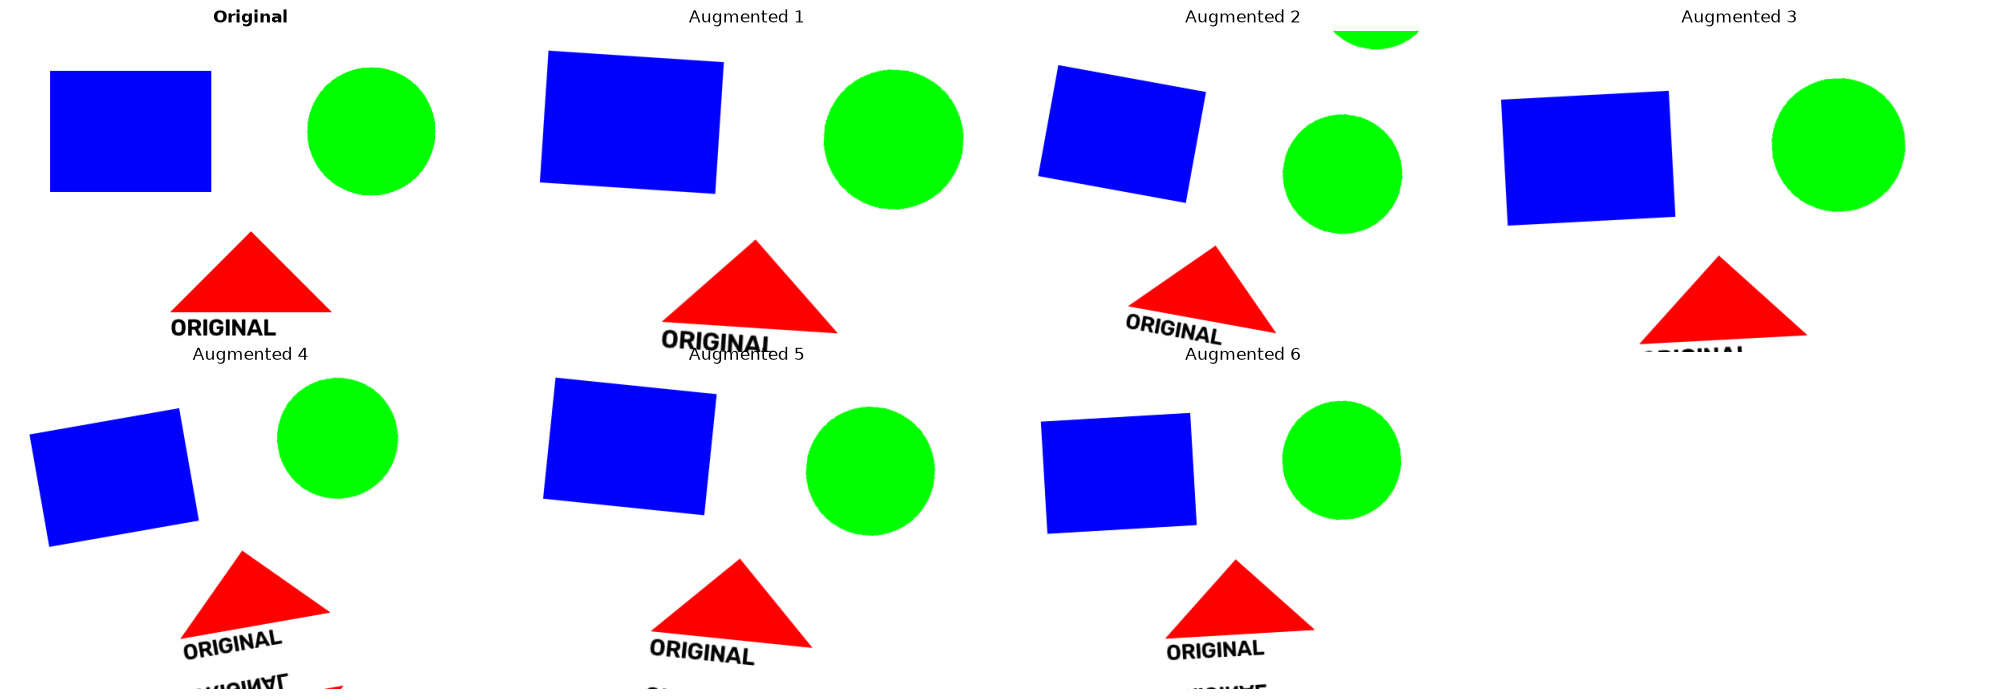

🎲 Generated 6 random augmentations!
Each has random:
  • Rotation (±15°)
  • Scale (90%-110%)
  • Translation (±30 pixels)

💡 In ML training, you'd generate these on-the-fly for each epoch!


In [16]:
# ============================================
# GENERATE MULTIPLE AUGMENTATIONS
# ============================================

# Set random seed for reproducibility (optional)
np.random.seed(42)

# Generate 6 random augmentations
num_augmentations = 6
augmented_images = [random_affine_augmentation(img) for _ in range(num_augmentations)]

# Display original + augmentations
plt.figure(figsize=(20, 7))

# Show original
plt.subplot(2, 4, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Original', fontsize=12, fontweight='bold')
plt.axis('off')

# Show augmentations
for i, aug_img in enumerate(augmented_images):
    plt.subplot(2, 4, i+2)
    plt.imshow(cv2.cvtColor(aug_img, cv2.COLOR_BGR2RGB))
    plt.title(f'Augmented {i+1}', fontsize=12)
    plt.axis('off')

plt.tight_layout()
plt.show()

print("🎲 Generated 6 random augmentations!")
print("Each has random:")
print("  • Rotation (±15°)")
print("  • Scale (90%-110%)")
print("  • Translation (±30 pixels)")
print("\n💡 In ML training, you'd generate these on-the-fly for each epoch!")

---

## 📊 Summary & Comparison

### 🔑 Key Functions Cheat Sheet

```python
# ============================================
# AFFINE TRANSFORMS (3 points)
# ============================================

# 1. Basic Affine Transform
M = cv2.getAffineTransform(src_points, dst_points)
result = cv2.warpAffine(img, M, (width, height))

# 2. Rotation (special case of affine)
M = cv2.getRotationMatrix2D(center, angle, scale)
rotated = cv2.warpAffine(img, M, (width, height))

# ============================================
# PERSPECTIVE TRANSFORM (4 points)
# ============================================

# 3. Perspective Transform
M = cv2.getPerspectiveTransform(src_points, dst_points)
result = cv2.warpPerspective(img, M, (width, height))

## 🎯 Practice Challenges

Try these exercises to master affine transformations:

### 🟢 Beginner
1. Rotate an image 90° clockwise
2. Scale an image to 50% of its original size
3. Flip an image horizontally using affine transform

### 🟡 Intermediate
4. Create a "mirror reflection" effect using shearing
5. Rotate an image around a corner (not the center)
6. Combine rotation + scaling + translation in one transform

### 🔴 Advanced
7. Build a function that automatically straightens a tilted document
8. Create a "3D card flip" effect using perspective transform
9. Implement automatic image alignment using feature matching

### 🏆 Expert
10. Build a data augmentation pipeline for ML training
11. Create a panorama stitcher using multiple affine transforms
12. Implement face alignment based on detected facial landmarks

---

## 💡 Tips for Practice

1. **Start simple** - Master rotation before combining transforms
2. **Visualize points** - Draw circles on source/destination points to understand
3. **Experiment** - Change parameters and see what happens
4. **Use real images** - Try with your own photos
5. **Check the matrix** - Print transformation matrices to understand the math

## 📚 What's Next?

Now that you've mastered affine transformations, here are the next topics:

### 🎯 Recommended Learning Path:

1. **Thresholding & Segmentation** 🎨
   - Separate objects from background
   - Binary, adaptive, Otsu's thresholding
   - Color-based segmentation

2. **Edge Detection** 🔍
   - Canny edge detector
   - Sobel, Laplacian operators
   - Find boundaries in images

3. **Contours** 📐
   - Detect and analyze shapes
   - Calculate area, perimeter
   - Bounding boxes and shape matching

4. **Video Processing** 🎥
   - Apply transforms in real-time
   - Webcam capture
   - Frame-by-frame processing

5. **Feature Detection** 🎯
   - SIFT, ORB, SURF
   - Automatic point matching
   - Image registration

---

## 🎉 Congratulations!

You've completed the **Affine Transformations** tutorial!

### ✅ You Can Now:
- ✅ Rotate images with precision
- ✅ Apply scaling, shearing, and translation
- ✅ Correct perspective distortion
- ✅ Align images automatically
- ✅ Augment data for machine learning
- ✅ Understand transformation matrices
- ✅ Combine multiple transforms efficiently

### 📖 Keep This Notebook:
Save this notebook as a reference guide. You can always come back to:
- Copy code snippets
- Review concepts
- Experiment with parameters

---

## 🚀 Ready for More?

Let me know which topic you'd like to learn next! 🎓

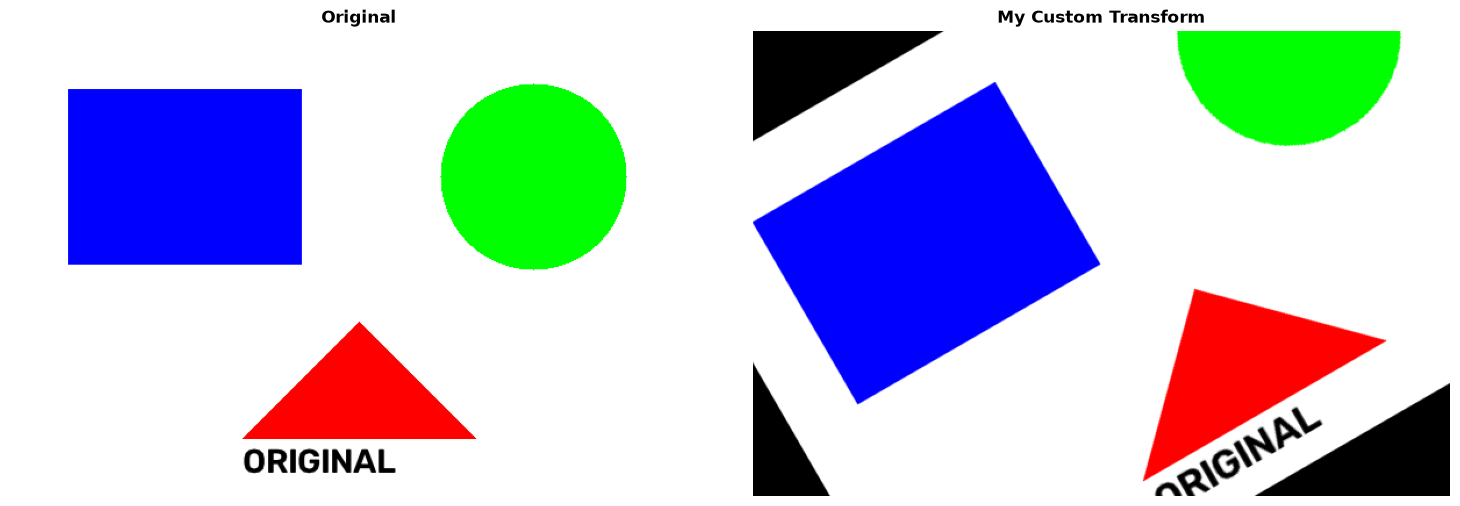

🎨 Your Custom Transformation:
   ↻ Rotation: 30°
   🔍 Scale: 1.2x
   ➡️  Shift: (50, -30) pixels

💡 Try changing the values above and run this cell again!


In [17]:
# ============================================
# PLAYGROUND: Experiment Here!
# ============================================

# Try your own transformation!
# Modify these values and see what happens:

my_angle = 30           # Change this: rotation angle
my_scale = 1.2          # Change this: scale factor
my_shift_x = 50         # Change this: horizontal shift
my_shift_y = -30        # Change this: vertical shift

# Apply your custom transformation
center = (cols // 2, rows // 2)
M_custom = cv2.getRotationMatrix2D(center, my_angle, my_scale)
M_custom[0, 2] += my_shift_x
M_custom[1, 2] += my_shift_y

my_result = cv2.warpAffine(img, M_custom, (cols, rows))

# Display
show_images([img, my_result], 
            ['Original', 'My Custom Transform'])

print("🎨 Your Custom Transformation:")
print(f"   ↻ Rotation: {my_angle}°")
print(f"   🔍 Scale: {my_scale}x")
print(f"   ➡️  Shift: ({my_shift_x}, {my_shift_y}) pixels")
print("\n💡 Try changing the values above and run this cell again!")